In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import ast
import seaborn as sns

df = pd.read_csv('/Users/phoebeyang/Downloads/data_jobs.csv')
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
import ast

df['job_skills'] = df['job_skills'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str)
    else x if isinstance(x, list)
    else []
)

Filters the original dataset to only get rows where the job title is 'Data Analyst' and the country is 'United States', to create a new DataFrame df_DA_US. Drop NaN values from the 'salary_year_avg' column. Then it uses the explode method on the job_skills column to create a new row in a new DataFrame (df_DA_US_exploded) for each skill associated with a job. Finally, it displays the first 5 entries of the salary_year_avg and job_skills columns.

In [2]:
df_DA_US = df[(df['job_title_short'] == 'Data Analyst') & (df['job_location'] == 'United States')]
df_DA_US = df_DA_US.dropna(subset=['salary_year_avg'])
df_DA_US_explode = df_DA_US.explode('job_skills')
df_DA_US_explode[['salary_year_avg', 'job_skills']]

,salary_year_avg,job_skills
18059,54000.0,sql
18059,54000.0,excel
18059,54000.0,ms access
19941,100500.0,python
19941,100500.0,sql
...,...,...
754319,89204.0,excel
771454,100500.0,python
771454,100500.0,r
771915,69900.0,word


Group the data by job skills and calculates the count and median salary for each skill, sorting the results in descending order by count. It then renames the columns. Calculates the percentage that each skill count represents out of the total number of Data Analyst jobs. Finally, filter out any skills that don't have any jobs associated with them.

In [7]:
df_DA_skills = df_DA_US_explode.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']).sort_values(by='count', ascending=False)
df_DA_skills = df_DA_skills.rename(columns={'count': 'skill_count', 'median': 'median_salary'})
DA_job_count = len(df_DA_US)
df_DA_skills['skill_percent'] = df_DA_skills['skill_count'] / DA_job_count * 100
df_DA_skills = df_DA_skills[df_DA_skills['skill_count'] >0]
df_DA_skills


,skill_count,median_salary,skill_percent
job_skills,,,
sql,20,88500.00,52.631579
tableau,16,88500.00,42.105263
python,15,100000.00,39.473684
excel,14,82258.75,36.842105
power bi,10,106400.00,26.315789
word,8,75033.75,21.052632
r,8,88500.00,21.052632
sharepoint,5,77017.50,13.157895
sas,4,93525.00,10.526316


In [9]:
skill_limit = 5
df_DA_skills_high_demand = df_DA_skills[df_DA_skills['skill_percent'] > skill_limit]

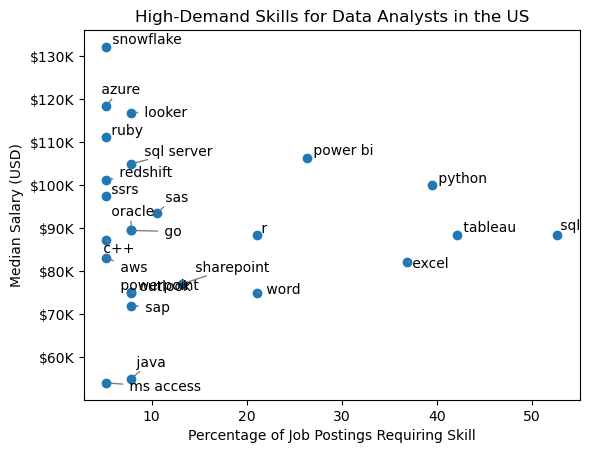

In [10]:
from adjustText import adjust_text
plt.scatter(df_DA_skills_high_demand['skill_percent'], df_DA_skills_high_demand['median_salary'])
plt.xlabel('Percentage of Job Postings Requiring Skill')
plt.ylabel('Median Salary (USD)')
plt.title('High-Demand Skills for Data Analysts in the US')

ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))

texts = []
for i, txt in enumerate(df_DA_skills_high_demand.index):
    texts.append(plt.text(df_DA_skills_high_demand['skill_percent'].iloc[i], df_DA_skills_high_demand['median_salary'].iloc[i], " " + txt))

# Adjust text to avoid overlap and add arrows
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray'))

plt.show()